# RL for Traffic-Light Control

**Goal:** Train a PPO agent to minimize intersection congestion using a lightweight, SIM-free environment (works on any laptop). Then compare against fixed baselines and visualize results.

**You will:**
1. Define a tiny 4-arm intersection simulator (`SimpleTrafficSignalEnv`).
2. Train **PPO** (Stable-Baselines3) on CPU.
3. Compare to baselines (fixed cycle, random, keep phase).
4. Plot average queue length and learning curves.


In [1]:
!nvidia-smi


Mon Jun 15 20:53:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce MX350           On  |   00000000:01:00.0 Off |                  N/A |
| N/A   56C    P8            N/A  / 5001W |       5MiB /   2048MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
"""!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121"""

'!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121'

In [3]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")          
    print('GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print('CPU')


GPU: NVIDIA GeForce MX350


In [4]:
#Setup (CPU-friendly installs)
import sys, subprocess, importlib, platform

def ensure(pkg, pip_name=None):
    pip_name = pip_name or pkg
    try:
        importlib.import_module(pkg)
        print(f"✓ {pkg} present")
    except Exception:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

print("Python:", sys.version.split()[0], "| OS:", platform.platform())

ensure("numpy")
ensure("matplotlib")
ensure("gymnasium")
ensure("stable_baselines3", "stable-baselines3")
print("Setup complete.")


Python: 3.13.5 | OS: Linux-6.14.0-34-generic-x86_64-with-glibc2.39
✓ numpy present
✓ matplotlib present
✓ gymnasium present


Matplotlib is building the font cache; this may take a moment.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


✓ stable_baselines3 present
Setup complete.


## Minimal traffic-signal environment

In [5]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

In [6]:
class SimpleTrafficSignalEnv(gym.Env):
    """
    Minimal intersection for RL (CPU-friendly):
    - Observation: [q_N, q_S, q_E, q_W, current_phase, time_in_phase_norm]
    - Action: 0=keep, 1=switch (only after min_green; adds yellow delay)
    - Reward: -sum(queues)  (minimize total queue length)
    """
    metadata = {"render_modes": ["human"], "render_fps": 4}

    def __init__(self,
                 max_queue=60,
                 mean_arrival_per_step=1.1,
                 service_rate=1.8,
                 min_green=5,
                 yellow=2,
                 episode_len=400,
                 seed=None):
        super().__init__()
        self.rng = np.random.default_rng(seed)
        self.max_queue = max_queue
        self.mean_arrival = mean_arrival_per_step
        self.service_rate = service_rate
        self.min_green = min_green
        self.yellow = yellow
        self.episode_len = episode_len

        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0,0.0], dtype=np.float32),
            high=np.array([max_queue,max_queue,max_queue,max_queue,1,1.0], dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(2)

        self.reset()

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.t = 0
        self.queues = np.zeros(4, dtype=np.float32)
        self.phase = 0                 # 0=NS green, 1=EW green
        self.time_in_phase = 0
        self.in_yellow = 0
        # for plotting
        self._history = {"total_queue": [], "phase": [], "yellow": [], "qN": [], "qS": [], "qE": [], "qW": []}
        return self._get_obs(), {}

    def step(self, action):
        self.t += 1

        # yellow handling & phase switching
        if self.in_yellow > 0:
            self.in_yellow -= 1
        else:
            if action == 1 and self.time_in_phase >= self.min_green:
                self.in_yellow = self.yellow
                self.time_in_phase = 0
                self.phase = 1 - self.phase
            else:
                self.time_in_phase += 1

        # arrivals (Poisson)
        arrivals = self.rng.poisson(self.mean_arrival, size=4).astype(np.float32)
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)

        # departures during green (if not yellow)
        if self.in_yellow == 0:
            if self.phase == 0:   # NS green
                self.queues[0] = max(0.0, self.queues[0] - self.service_rate)
                self.queues[1] = max(0.0, self.queues[1] - self.service_rate)
            else:                 # EW green
                self.queues[2] = max(0.0, self.queues[2] - self.service_rate)
                self.queues[3] = max(0.0, self.queues[3] - self.service_rate)

        total_q = float(np.sum(self.queues))
        reward = -total_q
        terminated = False
        truncated = self.t >= self.episode_len

        # log for plots
        self._history["total_queue"].append(total_q)
        self._history["phase"].append(int(self.phase))
        self._history["yellow"].append(int(self.in_yellow))
        self._history["qN"].append(float(self.queues[0]))
        self._history["qS"].append(float(self.queues[1]))
        self._history["qE"].append(float(self.queues[2]))
        self._history["qW"].append(float(self.queues[3]))

        return self._get_obs(), reward, terminated, truncated, {"total_queue": total_q}

    def _get_obs(self):
        return np.array([
            self.queues[0], self.queues[1], self.queues[2], self.queues[3],
            float(self.phase),
            min(1.0, self.time_in_phase / max(1, self.min_green))
        ], dtype=np.float32)

    def get_history(self):
        return self._history

In [7]:
# quick smoke test
env = SimpleTrafficSignalEnv(seed=42)
obs, _ = env.reset()
print("Initial obs shape:", obs.shape, "| Example obs:", obs)

Initial obs shape: (6,) | Example obs: [0. 0. 0. 0. 0. 0.]


## Baselines (fixed / keep / random) + rollout helper

In [8]:
def rollout(env_cfg, policy="fixed", steps=800, K=20, model=None, seed=123):
    env = SimpleTrafficSignalEnv(seed=seed, **env_cfg)
    obs, _ = env.reset()
    total_q = 0.0
    last_switch_t = 0
    for t in range(steps):
        if policy == "fixed":
            act = 1 if (t - last_switch_t) >= K else 0
            if act == 1:
                last_switch_t = t
        elif policy == "keep":
            act = 0
        elif policy == "random":
            act = np.random.randint(0, 2)
        elif policy == "rl":
            act, _ = model.predict(obs, deterministic=True)
        else:
            raise ValueError("Unknown policy")
        obs, r, term, trunc, info = env.step(int(act))
        total_q += info["total_queue"]
        if term or trunc:
            break
    hist = env.get_history()
    return total_q / steps, hist    

In [9]:
# try baselines
env_cfg = dict(mean_arrival_per_step=1.2, service_rate=1.8, episode_len=600, min_green=5, yellow=2)
for pol in ["keep", "random", "fixed"]:
    score, _ = rollout(env_cfg, policy=pol, steps=600, K=20)
    print(f"{pol:>6} avg total queue: {score:.2f} (lower is better)")


  keep avg total queue: 115.24 (lower is better)
random avg total queue: 206.71 (lower is better)
 fixed avg total queue: 195.40 (lower is better)


## Train PPO (Stable-Baselines3, CPU)

In [10]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

In [11]:
def make_env(env_cfg):
    def _fn():
        e = SimpleTrafficSignalEnv(**env_cfg)
        return Monitor(e)
    return _fn

In [12]:
train_env_cfg = dict(mean_arrival_per_step=1.2, service_rate=1.8, episode_len=400, min_green=5, yellow=2, seed=42)
vec = DummyVecEnv([make_env(train_env_cfg) for _ in range(2)])

In [13]:
model = PPO("MlpPolicy", vec, verbose=1, n_steps=256, batch_size=256, gamma=0.99)

Using cuda device


/home/chemousse/anaconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [14]:
model.learn(total_timesteps=100_000)  # small for CPU demo; increase later (e.g., 100k+)

----------------------------
| time/              |     |
|    fps             | 67  |
|    iterations      | 1   |
|    time_elapsed    | 7   |
|    total_timesteps | 512 |
----------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 400           |
|    ep_rew_mean          | -7.69e+04     |
| time/                   |               |
|    fps                  | 72            |
|    iterations           | 2             |
|    time_elapsed         | 14            |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 3.0170195e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.693        |
|    explained_variance   | -0.000332     |
|    learning_rate        | 0.0003        |
|    loss                 | 4.63e+06      |
|    n_updates            | 10            |
|    

-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 400           |
|    ep_rew_mean          | -7.96e+04     |
| time/                   |               |
|    fps                  | 2676          |
|    iterations           | 20            |
|    time_elapsed         | 3             |
|    total_timesteps      | 10240         |
| train/                  |               |
|    approx_kl            | 4.0187733e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.692        |
|    explained_variance   | 0.000373      |
|    learning_rate        | 0.0003        |
|    loss                 | 5.17e+06      |
|    n_updates            | 190           |
|    policy_gradient_loss | -6.21e-05     |
|    value_loss           | 1.02e+07      |
-------------------------------------------


In [15]:
model.save("ppo_tsc_cpu.zip")
print("Saved: ppo_tsc_cpu.zip")

Saved: ppo_tsc_cpu.zip


## Evaluate & plot

In [16]:
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

test_env_cfg = dict(mean_arrival_per_step=1.2, service_rate=1.8, episode_len=600, min_green=5, yellow=2)

In [17]:
# RL agent
rl = PPO.load("ppo_tsc_cpu.zip", device="cpu")
rl_score, rl_hist = rollout(test_env_cfg, policy="rl", steps=600, model=rl)

In [18]:
# Baselines
keep_score, keep_hist = rollout(test_env_cfg, policy="keep", steps=600)
rand_score, rand_hist = rollout(test_env_cfg, policy="random", steps=600)
fix_score, fix_hist = rollout(test_env_cfg, policy="fixed", steps=600, K=20)

In [19]:
print("Average total queue (lower is better):")
print(f"  RL (PPO): {rl_score:.2f}")
print(f"  Fixed-20: {fix_score:.2f}")
print(f"  Random  : {rand_score:.2f}")
print(f"  Keep    : {keep_score:.2f}")

Average total queue (lower is better):
  RL (PPO): 208.47
  Fixed-20: 195.40
  Random  : 206.46
  Keep    : 115.24


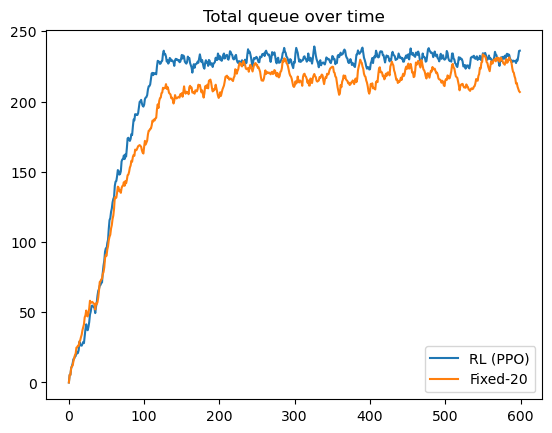

In [20]:
# Plot 1: Total queue over time (RL vs Fixed-20)
plt.figure()
plt.plot(rl_hist["total_queue"], label="RL (PPO)")
plt.plot(fix_hist["total_queue"], label="Fixed-20")
plt.title("Total queue over time")
plt.legend()
plt.show()

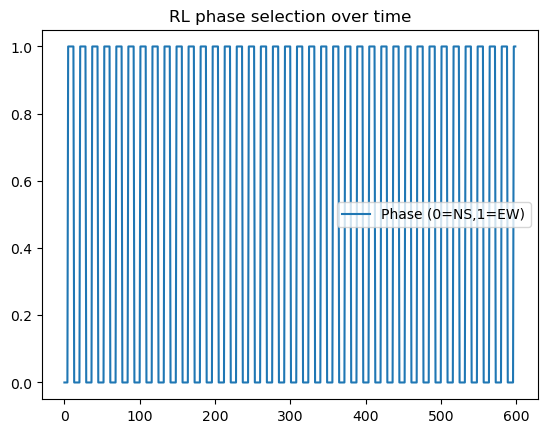

In [21]:
# Plot 2: Phase over time (RL)
plt.figure()
plt.plot(rl_hist["phase"], label="Phase (0=NS,1=EW)")
plt.title("RL phase selection over time")
plt.legend()
plt.show()


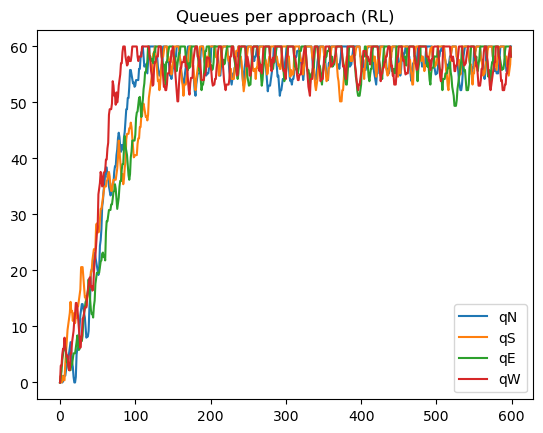

In [22]:
# Plot 3: Queue per approach (RL)
plt.figure()
plt.plot(rl_hist["qN"], label="qN")
plt.plot(rl_hist["qS"], label="qS")
plt.plot(rl_hist["qE"], label="qE")
plt.plot(rl_hist["qW"], label="qW")
plt.title("Queues per approach (RL)")
plt.legend()
plt.show()